In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [5]:
X_blobs, y_blobs = make_blobs(
    n_samples=600,
    centers=4,
    n_features=5,
    random_state=42
)

X_moons, y_moons = make_moons(
    n_samples=600, 
    noise=0.07, 
    random_state=42
)

In [6]:
scaler = StandardScaler()
X_blobs_scaled = scaler.fit_transform(X_blobs)
X_moons_scaled = scaler.fit_transform(X_moons)

In [7]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_blobs_scaled)

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_blobs_scaled)

In [8]:
tsne_2d = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne_2d = tsne_2d.fit_transform(X_blobs_scaled)

tsne_3d = TSNE(n_components=3, perplexity=30, random_state=42)
X_tsne_3d = tsne_3d.fit_transform(X_blobs_scaled)

In [19]:
print(pca_2d.explained_variance_ratio_)
print(np.cumsum(pca_2d.explained_variance_ratio_))

[0.44352159 0.32770968]
[0.44352159 0.77123127]


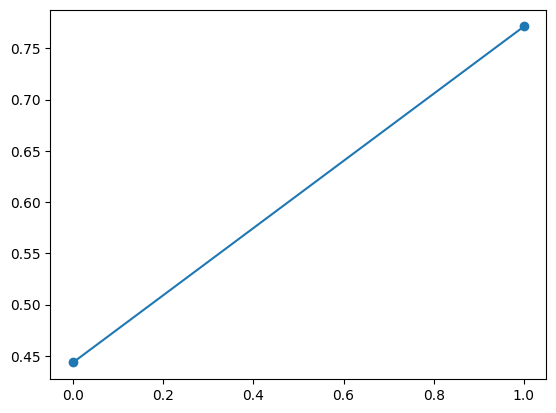

In [23]:
# scree plot for pca_2d
plt.plot(
    np.cumsum(pca_2d.explained_variance_ratio_),
    marker="o"
)

In [24]:
print(pca_3d.explained_variance_ratio_)
print(np.cumsum(pca_3d.explained_variance_ratio_))

[0.44352159 0.32770968 0.19887438]
[0.44352159 0.77123127 0.97010565]


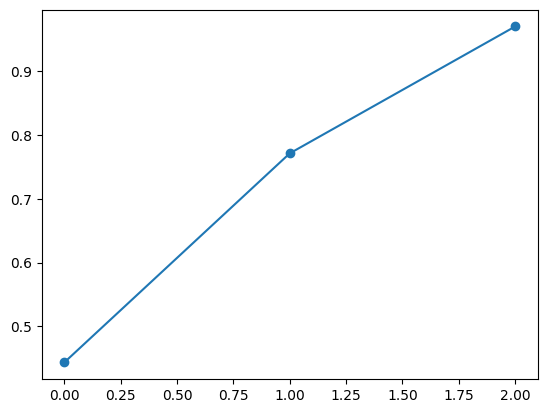

In [ ]:
# scree plot for pca_3d
plt.plot(
    np.cumsum(pca_3d.explained_variance_ratio_),
    marker="o"
)

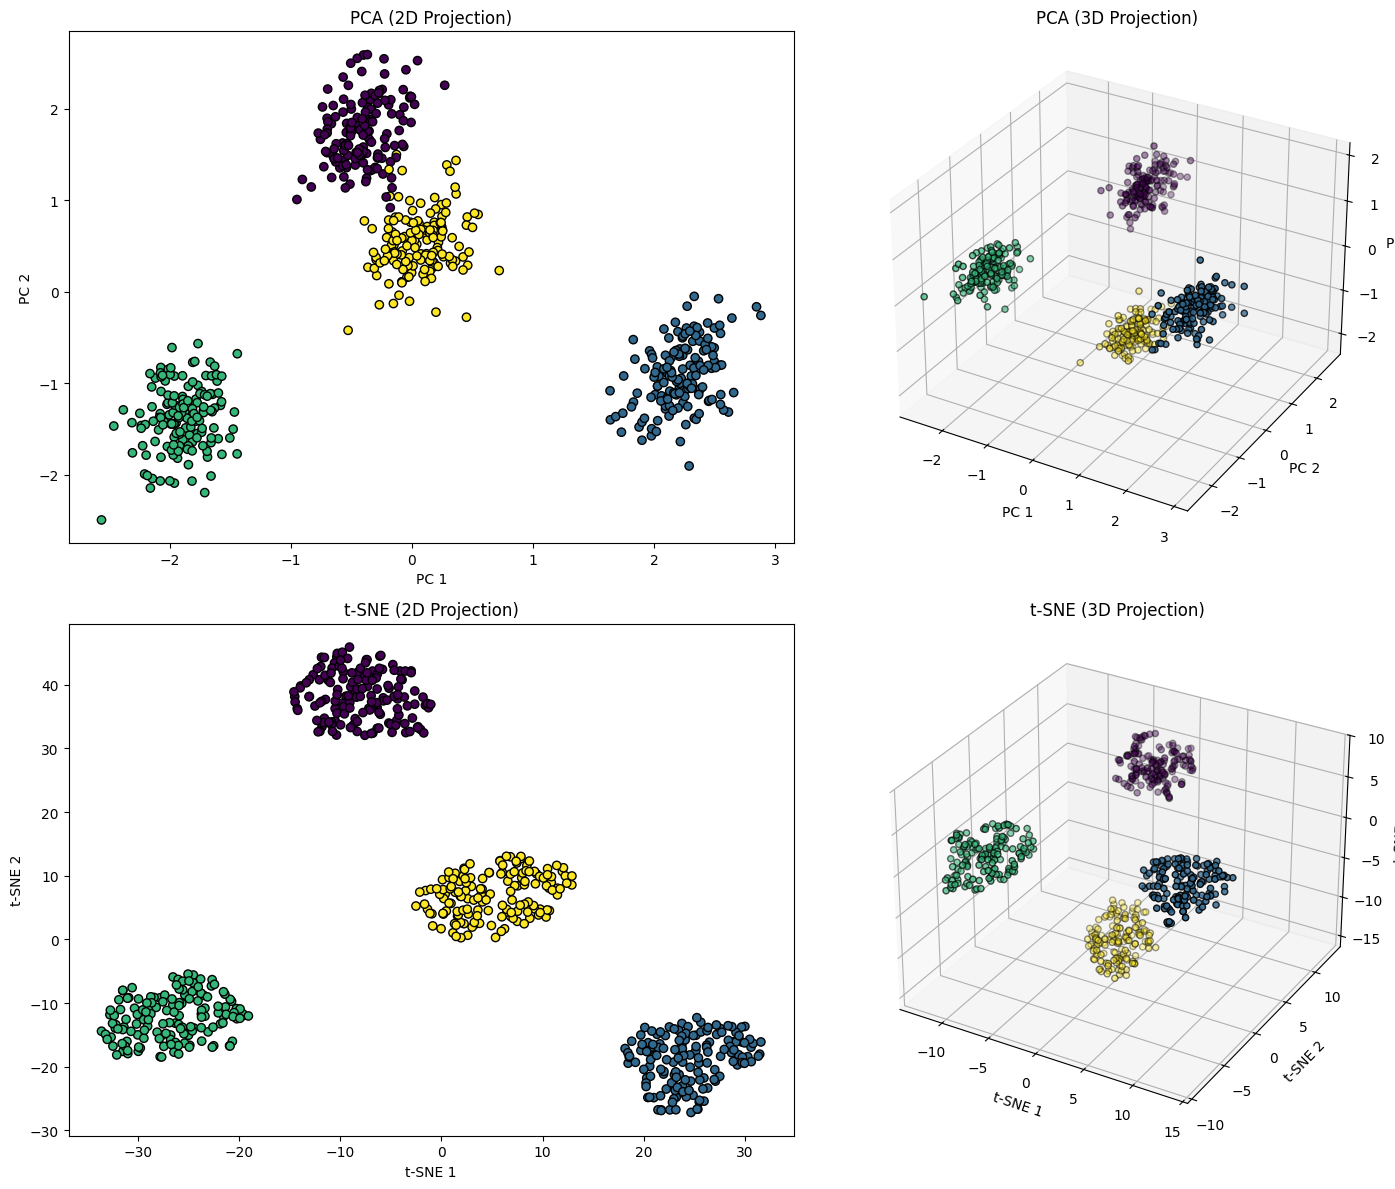

In [10]:
fig = plt.figure(figsize=(15, 12))

# PCA 2D Plot
ax1 = fig.add_subplot(2, 2, 1)
sc1 = ax1.scatter(
    X_pca_2d[:, 0], X_pca_2d[:, 1], c=y_blobs, cmap="viridis", edgecolor="k"
)
ax1.set_title("PCA (2D Projection)")
ax1.set_xlabel("PC 1")
ax1.set_ylabel("PC 2")

# PCA 3D Plot
ax2 = fig.add_subplot(2, 2, 2, projection="3d")
sc2 = ax2.scatter(
    X_pca_3d[:, 0],
    X_pca_3d[:, 1],
    X_pca_3d[:, 2],
    c=y_blobs,
    cmap="viridis",
    edgecolor="k",
)
ax2.set_title("PCA (3D Projection)")
ax2.set_xlabel("PC 1")
ax2.set_ylabel("PC 2")
ax2.set_zlabel("PC 3")

# --- t-SNE Subplots ---
# t-SNE 2D Plot
ax3 = fig.add_subplot(2, 2, 3)
sc3 = ax3.scatter(
    X_tsne_2d[:, 0], X_tsne_2d[:, 1], c=y_blobs, cmap="viridis", edgecolor="k"
)
ax3.set_title("t-SNE (2D Projection)")
ax3.set_xlabel("t-SNE 1")
ax3.set_ylabel("t-SNE 2")

# t-SNE 3D Plot
ax4 = fig.add_subplot(2, 2, 4, projection="3d")
sc4 = ax4.scatter(
    X_tsne_3d[:, 0],
    X_tsne_3d[:, 1],
    X_tsne_3d[:, 2],
    c=y_blobs,
    cmap="viridis",
    edgecolor="k",
)
ax4.set_title("t-SNE (3D Projection)")
ax4.set_xlabel("t-SNE 1")
ax4.set_ylabel("t-SNE 2")
ax4.set_zlabel("t-SNE 3")
plt.tight_layout()
plt.show()

In [11]:
pca_moons = PCA(n_components=2).fit_transform(X_moons_scaled)

tsne_moons = TSNE(
    n_components=2, 
    perplexity=30, 
    random_state=42
).fit_transform(X_moons_scaled)

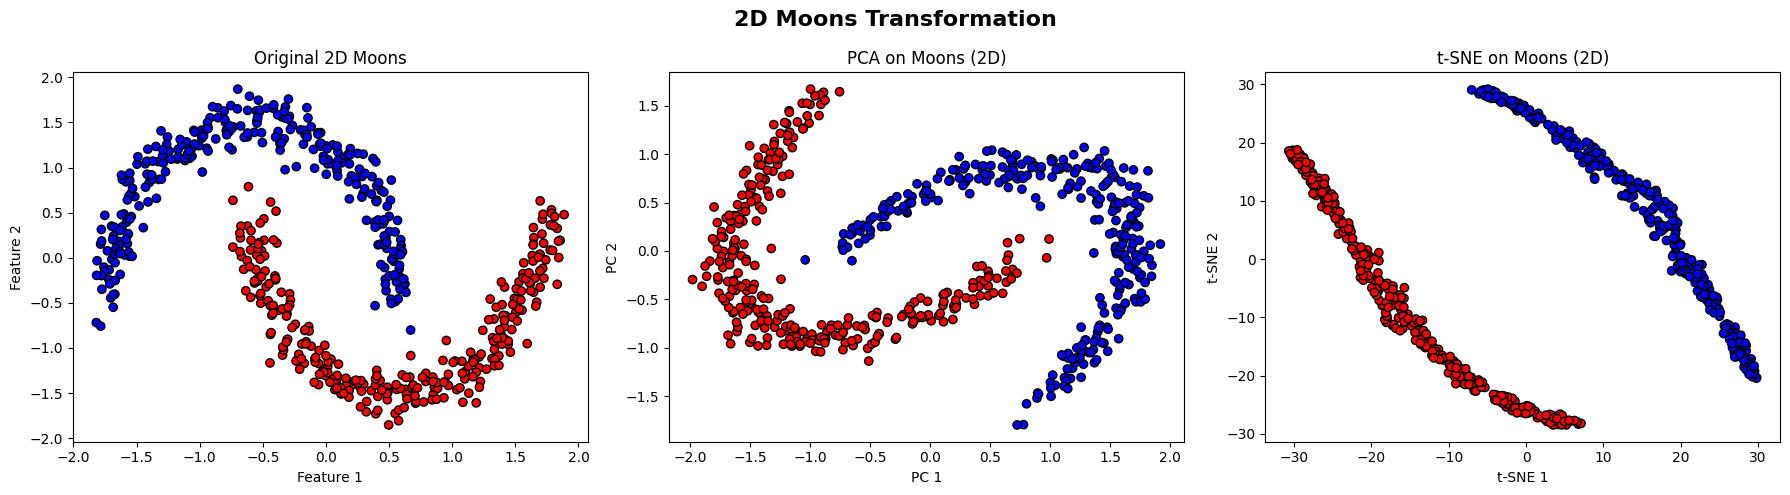

In [14]:
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
fig2.suptitle("2D Moons Transformation", fontsize=16, fontweight="bold")

axes2[0].scatter(
    X_moons_scaled[:, 0],
    X_moons_scaled[:, 1],
    c=y_moons,
    cmap="bwr",
    edgecolor="k",
)
axes2[0].set_title("Original 2D Moons")
axes2[0].set_xlabel("Feature 1")
axes2[0].set_ylabel("Feature 2")

axes2[1].scatter(
    pca_moons[:, 0], pca_moons[:, 1], c=y_moons, cmap="bwr", edgecolor="k"
)
axes2[1].set_title("PCA on Moons (2D)")
axes2[1].set_xlabel("PC 1")
axes2[1].set_ylabel("PC 2")

axes2[2].scatter(
    tsne_moons[:, 0], tsne_moons[:, 1], c=y_moons, cmap="bwr", edgecolor="k"
)
axes2[2].set_title("t-SNE on Moons (2D)")
axes2[2].set_xlabel("t-SNE 1")
axes2[2].set_ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

# Summary of Dimensionality Reduction & Visualization

During our discussion, we analyzed the performance of **PCA** and **t-SNE** on two toy datasets:

## 1. 5D Blobs (Dimensionality Reduction)
- **Data Setup**: Generated with 4 distinct clusters (`centers=4`) in a 5-dimensional feature space (`n_features=5`).
- **PCA (2D vs. 3D)**: PCA ranks the variance of the 5 original dimensions into Principal Components. The first 2 or 3 PCs contain the vast majority of the variance (information), while the 4th and 5th PCs contain almost none (noise/redundancy). By projecting onto PC1, PC2 (and PC3 for 3D), PCA successfully compresses the 5D space while keeping the 4 physical clusters clearly separated.
- **t-SNE (2D vs. 3D)**: t-SNE maps the 5D local neighbor distances down to a 2D or 3D coordinate system, compressing them into tight, highly separated clusters based on proximity, rather than preserving the global variance scale.

## 2. 2D Moons (Non-linear Manifolds)
- **Data Setup**: Generated as 2D interlocking crescents with moderate noise (`noise=0.07`).
- **PCA (2D)**: Because PCA only performs linear transformations (rotation and scaling), it cannot disentangle or "unravel" the interlocking non-linear moon shapes; they remain locked together.
- **t-SNE (2D)**: By focusing on local neighborhood connections, t-SNE successfully unrolls and separates the two crescents into two distinct, isolated clusters.